# Image Classification with Pre-trained Models (ResNet & Xception)

This notebook demonstrates image classification using two popular pre-trained Convolutional Neural Networks (CNNs): ResNet50 and Xception. We'll use sample images for ResNet50 and the `tf_flowers` dataset for Xception.

## 1. Setup and Imports

First, we'll install necessary libraries and import all the modules required for this notebook.

In [ ]:
# Install Pillow if not already present (ensure image loading works correctly)
# !pip install Pillow

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.datasets import load_sample_image
import tensorflow_datasets as tfds

## 2. ResNet50 for Image Classification (Sample Images)

We'll load sample images, preprocess them, and use a pre-trained ResNet50 model to classify them. This section also includes a brief demonstration of `tf.nn.conv2d` and `tf.nn.max_pool` operations.

In [ ]:
# Load sample images (scaled to 0-1 range)
china = load_sample_image("china.jpg") / 255
flower = load_sample_image("flower.jpg") / 255

images = np.array([china, flower], dtype=np.float32)
batch_size, height, width, channels = images.shape

print(f"Original image shape: {images.shape}")

# --- Convolution Operation Demo ---
# Create 2 simple 7x7 filters
filters = np.zeros(shape=(7, 7, channels, 2), dtype=np.float32)
filters[:, 3, :, 0] = 1  # Vertical line detector
filters[3, :, :, 1] = 1  # Horizontal line detector

# Apply convolution
outputs_conv = tf.nn.conv2d(images, filters, strides=1, padding="SAME")
print(f"Shape after convolution: {outputs_conv.shape}")

# Display the output of one of the convolutions
plt.figure(figsize=(10, 5))
plt.imshow(outputs_conv[0, :, :, 1], cmap="gray")
plt.title('Convolution Output (Horizontal Filter on China Image)')
plt.axis('off')
plt.show()

# --- Max Pooling Operation Demo ---
# Apply max pooling (e.g., to reduce channel depth for visualization)
# Note: ksize and strides should be carefully chosen. Here, just for demonstration.
# A stride of (1,1,1,3) on a 3-channel image will effectively average/select across channels.
output_pool = tf.nn.max_pool(images, ksize=(1, 1, 1, channels), strides=(1, 1, 1, channels), padding="VALID")
print(f"Shape after max pooling: {output_pool.shape}")

# Display max pooled images (they will appear grayscale due to channel reduction)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(output_pool[0, :, :, 0], cmap='viridis')
plt.title('Max Pooled China Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(output_pool[1, :, :, 0], cmap='viridis')
plt.title('Max Pooled Flower Image')
plt.axis('off')
plt.show()

# --- ResNet50 Prediction ---
# Load pre-trained ResNet50 model
print("\nLoading pre-trained ResNet50 model...")
resnet_model = keras.applications.resnet50.ResNet50(weights="imagenet")

# Resize images to ResNet's expected input size (224x224)
images_resized = tf.image.resize(images, [224, 224])

# Preprocess images for ResNet50 (expects input in a specific range, often 0-255 or normalized)
# `preprocess_input` handles the specific normalization for the model
inputs_resnet = keras.applications.resnet50.preprocess_input(images_resized * 255)

# Make predictions
Y_proba_resnet = resnet_model.predict(inputs_resnet)

# Decode predictions to human-readable labels
topK_resnet = keras.applications.resnet50.decode_predictions(Y_proba_resnet, top=5)

print("\nResNet50 Predictions:")
for image_index in range(len(images)):
  print(f"Image #{image_index}")
  for class_id, name, y_proba in topK_resnet[image_index]:
    print(f"  - {name:<12s} {y_proba*100:.2f}%")
  print()

## 3. Xception Model for Flower Classification

Here, we'll fine-tune a pre-trained Xception model on the `tf_flowers` dataset. This involves loading the dataset, splitting it, defining preprocessing steps, building a new classification head, and then training the model.

In [ ]:
# Load the tf_flowers dataset
print("Loading tf_flowers dataset...")
dataset, info = tfds.load("tf_flowers", as_supervised=True, with_info=True)

dataset_size = info.splits["train"].num_examples
class_names = info.features["label"].names
n_classes = info.features["label"].num_classes

print(f"Class Names: {class_names}")
print(f"Dataset Size: {dataset_size}")
print(f"Number of Classes: {n_classes}")
# print("Dataset Info:\n", info)

# Split the dataset into training, validation, and test sets
test_split_str = 'train[:10%]'
valid_split_str = 'train[10%:25%]'
train_split_str = 'train[25%:]'

test_set = tfds.load("tf_flowers", split=test_split_str, as_supervised=True)
valid_set = tfds.load("tf_flowers", split=valid_split_str, as_supervised=True)
train_set = tfds.load("tf_flowers", split=train_split_str, as_supervised=True)

print("Dataset splits created.")

In [ ]:
# Preprocessing function for Xception
def preprocess_xception(image, label):
  # Xception expects 224x224 input
  resized_image = tf.image.resize(image, [224, 224])
  # Xception specific preprocessing (normalizes pixels to range -1 to 1)
  final_image = keras.applications.xception.preprocess_input(resized_image)
  return final_image, label

# Apply preprocessing and batching to datasets
batch_size = 32

train_set = train_set.shuffle(1000).map(preprocess_xception).batch(batch_size).prefetch(1)
valid_set = valid_set.map(preprocess_xception).batch(batch_size).prefetch(1)
test_set = test_set.map(preprocess_xception).batch(batch_size).prefetch(1)

print("Datasets preprocessed and batched.")

In [ ]:
# Build the Xception model for fine-tuning
print("Building Xception model...")
# Load Xception base model with pre-trained ImageNet weights, excluding the top classification layer
base_model = keras.applications.xception.Xception(weights="imagenet", include_top=False)

# Add a GlobalAveragePooling2D layer to flatten the output of the base model
avg = keras.layers.GlobalAveragePooling2D()(base_model.output)

# Add a new dense output layer for our specific number of flower classes
output = keras.layers.Dense(n_classes, activation="softmax")(avg)

# Create the final model
model = keras.Model(inputs=base_model.input, outputs=output)

print("Xception model architecture:")
model.summary()

# Freeze the base model layers initially (transfer learning - feature extraction)
for layer in base_model.layers:
  layer.trainable = False

# Compile the model for initial training of the new classification head
optimizer = keras.optimizers.SGD(learning_rate=0.2, momentum=0.9) # decay is deprecated in newer Keras versions
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])

print("\nStarting initial training (training only the new head)...")
history_initial = model.fit(train_set, epochs=5, validation_data=valid_set)

# Unfreeze all layers for fine-tuning
for layer in base_model.layers:
  layer.trainable = True

# Recompile the model with a lower learning rate for fine-tuning
optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True) # decay is deprecated
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])

print("\nStarting fine-tuning (training all layers)...")
history_finetune = model.fit(train_set, epochs=5, validation_data=valid_set)

print("\nTraining complete.")

## 4. Evaluate the Fine-tuned Xception Model

Finally, let's evaluate the performance of our fine-tuned Xception model on the test set.

In [ ]:
print("\nEvaluating the model on the test set...")
loss, accuracy = model.evaluate(test_set)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy*100:.2f}%")

In [ ]:
pip install Pillow

In [ ]:
from sklearn.datasets import load_sample_image
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow import keras

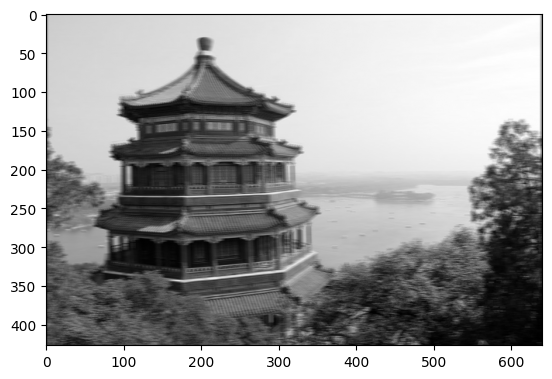

In [ ]:
# load sample images
china = load_sample_image("china.jpg") / 255
flower = load_sample_image("flower.jpg") / 255

images = np.array([china, flower])
batch_size, height, width, channels = images.shape

#create 2 filters
filters = np.zeros(shape=(7,7, channels, 2), dtype =np.float32)

filters[:, 3, :, 0] = 1
filters[3, :, :, 1] = 1

outputs = tf.nn.conv2d(images, filters, strides = 1, padding = "SAME")

plt.imshow(outputs[0, :, :, 1], cmap = "gray")
plt.show()

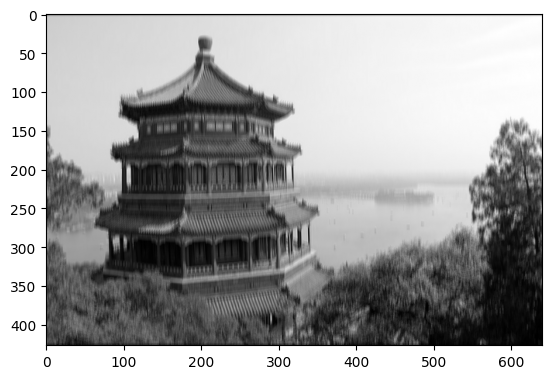

In [ ]:
plt.imshow(outputs[0, :, :, 0], cmap = "gray")
plt.show()

In [ ]:
images.shape

(2, 427, 640, 3)

In [ ]:
images[0].shape

(427, 640, 3)

In [ ]:
outputs.shape

TensorShape([2, 427, 640, 2])

In [ ]:
filters.shape

(7, 7, 3, 2)

In [ ]:
output2 = tf.nn.max_pool(images,
                         ksize=(1,1,1,3 ),
                         strides = (1,1,1,3),
                         padding = "VALID")

In [ ]:
output2.shape

TensorShape([2, 427, 640, 1])

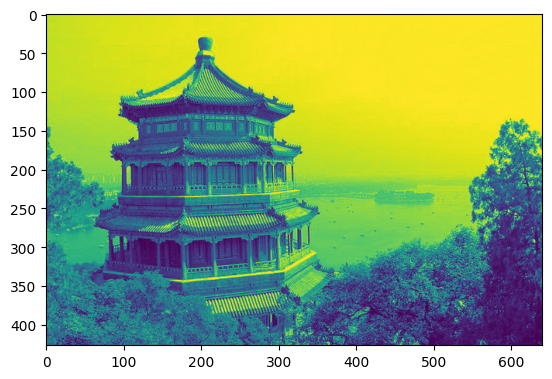

In [ ]:
plt.imshow(output2[0, :, :, :])
plt.show()

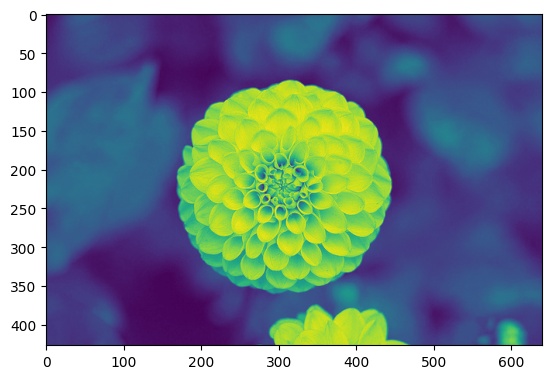

In [ ]:
plt.imshow(output2[1, :, :, :])
plt.show()

##Using pre-trained models

### 1. ResNet

In [ ]:
model = keras.applications.resnet50.ResNet50(weights = "imagenet")

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
images.shape

(2, 427, 640, 3)

In [ ]:
images_resized = tf.image.resize(images, [224, 224])

In [ ]:
inputs = keras.applications.resnet50.preprocess_input(images_resized *255)

In [ ]:
Y_proba  = model.predict(inputs)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


In [ ]:
Y_proba

array([[2.09246469e-08, 6.21202503e-08, 3.48997773e-08, ...,
        3.07011638e-09, 1.33173771e-07, 8.02847637e-08],
       [5.96663412e-08, 4.53567336e-05, 2.23037304e-07, ...,
        3.22427695e-05, 2.91647483e-03, 1.08517215e-05]], dtype=float32)

In [ ]:
topK = keras.applications.resnet50.decode_predictions(Y_proba, top=5)

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
for image_index in range(len(images)):
  print("Image #{}".format(image_index))
  for class_id, name, y_proba in topK[image_index]:
    print(" {} -{:12s} {:.2f}%".format(class_id, name, y_proba*100))
  print()

Image #0
 n02825657 -bell_cote    82.35%
 n03877845 -palace       6.75%
 n03781244 -monastery    4.19%
 n02980441 -castle       3.16%
 n03028079 -church       1.00%

Image #1
 n03530642 -honeycomb    49.81%
 n13040303 -stinkhorn    33.96%
 n02206856 -bee          4.35%
 n11939491 -daisy        3.23%
 n12985857 -coral_fungus 2.66%



###2. Xception

In [ ]:
import tensorflow_datasets as tfds

In [ ]:
#pip install --upgrade protobuf

In [ ]:
dataset, info = tfds.load("tf_flowers",   as_supervised=True, with_info= True)
dataset_size = info.splits["train"].num_examples
class_names = info.features["label"].names
n_classes = info.features["label"].num_classes

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.1DP43U_3.0.1/tf_flowers-train.tfrecord-[0-9][0-9][0-…

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.


In [ ]:
print(class_names)
print(dataset_size)
print(n_classes)
print(info)

['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']
3670
5
tfds.core.DatasetInfo(
    name='tf_flowers',
    full_name='tf_flowers/3.0.1',
    description="""
    A large set of images of flowers
    """,
    homepage='https://www.tensorflow.org/tutorials/load_data/images',
    data_dir='/root/tensorflow_datasets/tf_flowers/3.0.1',
    file_format=tfrecord,
    download_size=218.21 MiB,
    dataset_size=221.83 MiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=5),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=3670, num_shards=2>,
    },
    citation="""@ONLINE {tfflowers,
    author = "The TensorFlow Team",
    title = "Flowers",
    month = "jan",
    year = "2019",
    url = "http://download.tensorflow.org/example_images/flower_photos.tgz" }""",
)


In [ ]:
# Instead of using .subsplit(), define the splits using string slicing directly.
# The 'train' split will be divided into test (10%), validation (15%), and train (75%).
test_split_str = 'train[:10%]' # First 10% of the training data for testing
valid_split_str = 'train[10%:25%]' # Next 15% (from 10% to 25%) for validation
train_split_str = 'train[25%:]' # Remaining 75% (from 25% to 100%) for training

test_set = tfds.load("tf_flowers", split=test_split_str, as_supervised=True)
valid_set = tfds.load("tf_flowers", split=valid_split_str, as_supervised=True)
train_set = tfds.load("tf_flowers", split=train_split_str, as_supervised=True)

In [ ]:
def preprocess(image, label):
  resized_image = tf.image.resize(image, [224,224])
  final_image = keras.applications.xception.preprocess_input(resized_image)
  return final_image, label

In [ ]:
batch_size = 32
train_set = train_set.shuffle(1000)
train_set = train_set.map(preprocess).batch(batch_size).prefetch(1)
valid_set = valid_set.map(preprocess).batch(batch_size).prefetch(1)
test_set = test_set.map(preprocess).batch(batch_size).prefetch(1)

In [ ]:
#loading the xception model

base_model = keras.applications.xception.Xception(weights = "imagenet", include_top = False)
avg = keras.layers.GlobalAveragePooling2D()(base_model.output)
output = keras.layers.Dense(n_classes, activation="softmax")(avg)
model = keras.Model(inputs=base_model.input, outputs = output)

In [ ]:
for index,layer in enumerate(base_model.layers):
  print(index, layer.name)

0 input_layer_1
1 block1_conv1
2 block1_conv1_bn
3 block1_conv1_act
4 block1_conv2
5 block1_conv2_bn
6 block1_conv2_act
7 block2_sepconv1
8 block2_sepconv1_bn
9 block2_sepconv2_act
10 block2_sepconv2
11 block2_sepconv2_bn
12 conv2d_4
13 block2_pool
14 batch_normalization_4
15 add_12
16 block3_sepconv1_act
17 block3_sepconv1
18 block3_sepconv1_bn
19 block3_sepconv2_act
20 block3_sepconv2
21 block3_sepconv2_bn
22 conv2d_5
23 block3_pool
24 batch_normalization_5
25 add_13
26 block4_sepconv1_act
27 block4_sepconv1
28 block4_sepconv1_bn
29 block4_sepconv2_act
30 block4_sepconv2
31 block4_sepconv2_bn
32 conv2d_6
33 block4_pool
34 batch_normalization_6
35 add_14
36 block5_sepconv1_act
37 block5_sepconv1
38 block5_sepconv1_bn
39 block5_sepconv2_act
40 block5_sepconv2
41 block5_sepconv2_bn
42 block5_sepconv3_act
43 block5_sepconv3
44 block5_sepconv3_bn
45 add_15
46 block6_sepconv1_act
47 block6_sepconv1
48 block6_sepconv1_bn
49 block6_sepconv2_act
50 block6_sepconv2
51 block6_sepconv2_bn
52 blo

In [ ]:
for layer in base_model.layers:
  layer.trainable = False

optimizer = keras.optimizers.SGD(learning_rate = 0.2, momentum = 0.9, decay = 0.01)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])
history = model.fit(train_set, epochs=5, validation_data = valid_set)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


86/86 ━━━━━━━━━━━━━━━━━━━━ 862s 10s/step - accuracy: 0.7682 - loss: 1.8535 - val_accuracy: 0.8113 - val_loss: 1.8864
Epoch 2/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 833s 10s/step - accuracy: 0.8859 - loss: 0.9081 - val_accuracy: 0.8367 - val_loss: 1.3538
Epoch 3/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 823s 10s/step - accuracy: 0.9215 - loss: 0.4819 - val_accuracy: 0.8603 - val_loss: 1.1986
Epoch 4/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 831s 10s/step - accuracy: 0.9528 - loss: 0.1983 - val_accuracy: 0.8512 - val_loss: 1.2172
Epoch 5/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 824s 10s/step - accuracy: 0.9651 - loss: 0.1404 - val_accuracy: 0.8639 - val_loss: 1.0437


In [ ]:
for layer in base_model.layers:
  layer.trainable = True

optimizer = keras.optimizers.SGD(learning_rate = 0.01, momentum = 0.9, nesterov = True, decay = 0.001)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])
history = model.fit(train_set, epochs=5, validation_data = valid_set)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


86/86 ━━━━━━━━━━━━━━━━━━━━ 2946s 34s/step - accuracy: 0.8786 - loss: 0.3940 - val_accuracy: 0.8802 - val_loss: 0.4774
Epoch 2/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 2914s 34s/step - accuracy: 0.9797 - loss: 0.0674 - val_accuracy: 0.9002 - val_loss: 0.3042
Epoch 3/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 2903s 34s/step - accuracy: 0.9887 - loss: 0.0309 - val_accuracy: 0.9129 - val_loss: 0.2734
Epoch 4/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 2968s 34s/step - accuracy: 0.9956 - loss: 0.0148 - val_accuracy: 0.9038 - val_loss: 0.3418
Epoch 5/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 2951s 34s/step - accuracy: 0.9916 - loss: 0.0268 - val_accuracy: 0.8875 - val_loss: 0.3999
